In [2]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import os
import sys
sys.path.append('..')

# Import preprocess_image function
from backend.model import preprocess_image, predict, class_names
from backend.model import load_model_once

In [3]:
#Load model
# Load the model (using your function)
from backend.model import model
if model is None:
    load_model_once()

#Class names (must match training)
class_names = ['Cyst', 'Normal', 'Stone', 'Tumor']
print(f"Classes: {class_names}")

E0000 00:00:1775823374.219833  118757 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model loaded from /home/milka/code/Tch25/CT_Kidney_Classifier/backend/../backend/../model/custom_cnn_kidney_model.h5
Classes: ['Cyst', 'Normal', 'Stone', 'Tumor']


## Load image

In [5]:
# Load image
#image_path = '../test_images/Stone/Stone- (5).jpg'
image_path = '/home/milka/code/Tch25/kidney dataset/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone/Stone/Stone- (3).jpg'
img = Image.open(image_path)
img_array = np.array(img)

processed_img = preprocess_image(img_array)  # Returns (1, 224, 224, 3)

print(f"Preprocessed shape: {processed_img.shape}")

# Make prediction
result = predict(img_array)
print(f"Prediction: {result['prediction']} ({result['confidence']:.1%})")

Preprocessed shape: (1, 224, 224, 3)
Prediction: Stone (100.0%)


## Grad-cam

In [6]:
#inspect model layers to find the last conv layer
print("Model layers")
for i, layer in enumerate(model.layers):
    print(f"{i}: {layer.name} - {layer.__class__.__name__}")

#Find the last convolutional layer
last_conv_layer = None
for layer in reversed(model.layers):
    if 'conv' in layer.name.lower():
        last_conv_layer = layer
        break
print(f"\nLast convolutional layer: {last_conv_layer.name}")


Model layers


AttributeError: 'NoneType' object has no attribute 'layers'

In [65]:
def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Generates a Grad-CAM heatmap for a given image and model.

    Parameters:
    -----------
    img_array : numpy array
        The input image tensor (must include batch dimension, e.g., (1, 224, 224, 3)).
    model : tf.keras.Model
        The trained classification model.
    last_conv_layer_name : str
        The name of the last convolutional layer (e.g., 'conv2d_3').
    pred_index : int, optional
        The index of the class to visualize. If None, uses the model's top prediction.

    Returns:
    --------
    heatmap : numpy array
        A 2D heatmap (float32) of shape (H, W) with values between 0 and 1.
    """
    # 1. Find the index of your target Conv layer
    conv_layer_index = None
    for i, layer in enumerate(model.layers):
        if layer.name == last_conv_layer_name:
            conv_layer_index = i
            break

    if conv_layer_index is None:
        raise ValueError(f"Could not find layer named {last_conv_layer_name}")

    # 2. Run the image through the model manually
    with tf.GradientTape() as tape:
        x = tf.cast(img_array, tf.float32)

        # A. Run through layers UP TO the conv layer
        for layer in model.layers[:conv_layer_index + 1]:
            x = layer(x)

        # B. Capture the conv output
        conv_output = x
        tape.watch(conv_output)

        # C. Run through the REMAINING layers (Flatten, Dense, Dropout, etc.)
        for layer in model.layers[conv_layer_index + 1:]:
            x = layer(x)

        preds = x

        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # 3. Calculate Gradients
    grads = tape.gradient(class_channel, conv_output)

    # 4. Global Average Pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 5. Multiply and create heatmap
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]

    # 6. Post-Processing
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if max_val > 0:
        heatmap /= max_val
    else:
        heatmap = tf.zeros(heatmap.shape)

    # Return as 2D numpy array
    heatmap_2d = tf.squeeze(heatmap).numpy()

    return heatmap_2d

### Convert heatmap to bounding box

In [66]:
def heatmap_to_bbox(heatmap, original_shape, threshold = 0.5, min_size = 20):
    """
    Convert Grad-CAM heatmap to bounding box coordinates

    Args:
        heatmap: numpy array (H, W)
            The heatmap from grad-CAM (values 0-1)
        original_shape: tuple (h, w)
            Shape of the original image
        threshold: float
            Minimum heatmap value to consider (0.5 = top 50%)
        min_size = int
            Minimum box size in pixels

    Returns:
        bbox: tuple (x_min, y_min, x_max, y_max) or None
            Bounding box coordinates in original image space

    """
    #upscaled heatmap to orginal size
    h, w = original_shape[:2]
    heatmap_resized = cv2.resize(heatmap, (h, w))

    #Find pixels above threshold
    y_coords, x_coords = np.where(heatmap_resized > threshold)

    if len(y_coords) == 0:
        return None

    #Get bbox coordinates
    x_min, x_max = x_coords.min(), x_coords.max()
    y_min, y_max = y_coords.min(), y_coords.max()

    #Ensure min size
    if (x_max -x_min) < min_size:
        center = (x_min + x_max) // 2
        x_min = max(0, center - min_size // 2)
        x_max = min(w, center + min_size // 2)

    if (y_max - y_min) < min_size:
        center = (y_min + y_max) // 2
        y_min = max(0, center - min_size // 2)
        y_max = min(h, center + min_size // 2)

    return (int(x_min), int(y_min), int(x_max), int(y_max))

In [67]:
def draw_bbox(image, bbox, color=(255, 0, 0), thickness=2):
    """
    Draw bounding box on image.

    Parameters:
    -----------
    image : numpy array
        Original image (H, W, 3)
    bbox : tuple (x_min, y_min, x_max, y_max)
        Bounding box coordinates
    color : tuple (B, G, R)
        Box color (default: red)
    thickness : int
        Line thickness

    Returns:
    --------
    image_with_bbox : numpy array
        Image with bounding box drawn
    """
    img_copy = image.copy()
    x_min, y_min, x_max, y_max = bbox
    cv2.rectangle(img_copy, (x_min, y_min), (x_max, y_max), color, thickness)

    return img_copy

In [ ]:
def overlay_heatmap(image, heatmap, alpha=0.5):
    h, w = image.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(image.astype(np.uint8), 1 - alpha, heatmap_colored, alpha, 0)
    return overlay


In [122]:
# Generate heatmap for image
heatmap = get_gradcam_heatmap(
    img_array=processed_img,
    model=model,
    last_conv_layer_name="conv2d_3"
)

print("Heatmap generated")
print(f"Shape: {heatmap.shape}")
print(f"Min: {heatmap.min():.3f}, Max: {heatmap.max():.3f}")

Heatmap generated
Shape: (28, 28)
Min: 0.000, Max: 1.000


In [123]:
# Load original image
bbox = heatmap_to_bbox(heatmap, img_array.shape, threshold=0.5)

print("Bounding box calculated")
print(f"Bbox: {bbox}")

Bounding box calculated
Bbox: (256, 253, 360, 290)


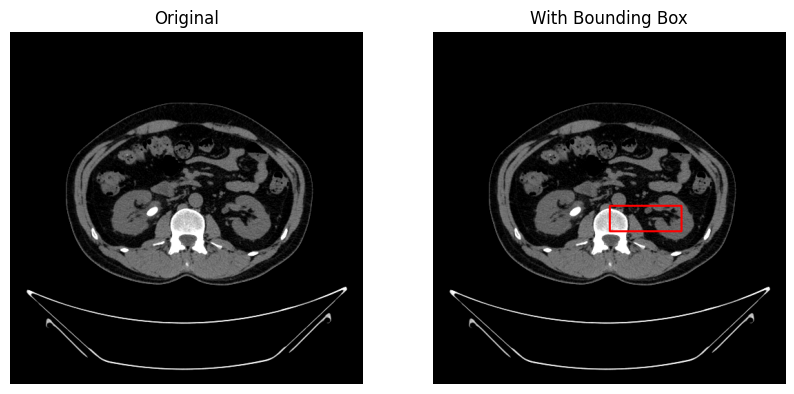

In [124]:
#Draw bounding box
if bbox:
    img_with_bbox = draw_bbox(img_array, bbox, color=(255, 0, 0), thickness=2)

    # Display
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_array)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_with_bbox)
    plt.title("With Bounding Box")
    plt.axis('off')

    plt.show()
else:
    print("No bounding box found")

Bounding box calculated
Bbox: (256, 253, 360, 290)


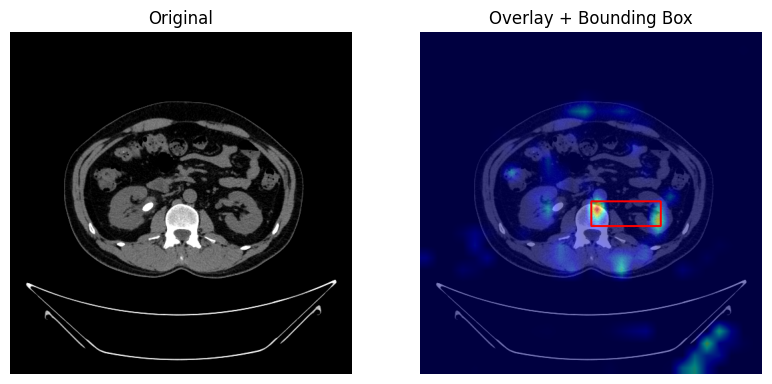

In [125]:
# Create overlay
overlay = overlay_heatmap(img_array, heatmap, alpha=0.5)

# Load original image
bbox = heatmap_to_bbox(heatmap, img_array.shape, threshold=0.5)

print("Bounding box calculated")
print(f"Bbox: {bbox}")

# Draw bounding box and display ALL THREE
if bbox:
    img_with_bbox = draw_bbox(img_array, bbox, color=(255, 0, 0), thickness=2)
    overlay_with_bbox = draw_bbox(overlay, bbox, color=(255, 0, 0), thickness=2)

    # Display three images
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(img_array)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(overlay_with_bbox)
    plt.title("Overlay + Bounding Box")
    plt.axis('off')

    plt.show()
else:
    print("No bounding box found - showing heatmap overlay only")

    # Display original and overlay
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_array)
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title("Heatmap Overlay (No Box)")
    plt.axis('off')

    plt.show()

## Test several images 

In [127]:
# Test several stone images and see if bounding boxes are consistent
stone_images = [f for f in os.listdir('../test_images/Stone/') if f.endswith('.jpg')][:5]

for stone_file in stone_images:
    image_path = f'../test_images/Stone/{stone_file}'
    img = Image.open(image_path)
    img_array = np.array(img)
    processed = preprocess_image(img_array)

    # Get heatmap and bbox
    heatmap = get_gradcam_heatmap(processed, model, "conv2d_3")
    bbox = heatmap_to_bbox(heatmap, img_array.shape, threshold=0.5)

    print(f"\n{stone_file}:")
    print(f"  Prediction: {predict(img_array)['prediction']}")
    print(f"  Bbox: {bbox}")

    if bbox:
        x_min, y_min, x_max, y_max = bbox
        print(f"  Box size: {x_max-x_min} × {y_max-y_min}")


Stone- (6).jpg:
  Prediction: Stone
  Bbox: (256, 250, 449, 471)
  Box size: 193 × 221

Stone- (1).jpg:
  Prediction: Stone
  Bbox: (204, 253, 274, 344)
  Box size: 70 × 91

Stone- (2).jpg:
  Prediction: Stone
  Bbox: (205, 252, 431, 468)
  Box size: 226 × 216

Stone- (3).jpg:
  Prediction: Stone
  Bbox: (202, 253, 449, 471)
  Box size: 247 × 218

Stone- (4).jpg:
  Prediction: Stone
  Bbox: (207, 254, 432, 469)
  Box size: 225 × 215


In [51]:
# Full pipeline for any image
def analyze_image(image_path, model, last_conv_layer_name, threshold=0.5):
    """
    Complete analysis: prediction + heatmap + bbox + overlay
    """
    # Load and preprocess
    img = Image.open(image_path)
    img_array = np.array(img)
    processed = preprocess_image(img_array)

    # Predict
    result = predict(img_array)

    # Generate heatmap
    heatmap = get_gradcam_heatmap(
        processed, model, last_conv_layer_name
    )

    # Get bounding box (only for abnormal)
    bbox = None
    if result['prediction'] != 'Normal':
        bbox = heatmap_to_bbox(heatmap, img_array.shape, threshold=threshold)

    # Create overlay
    overlay = overlay_heatmap(img_array, heatmap, alpha=0.5)

    # Draw bbox on overlay if exists
    if bbox:
        overlay_with_bbox = draw_bbox(overlay, bbox)
    else:
        overlay_with_bbox = overlay

    return {
        'prediction': result['prediction'],
        'confidence': result['confidence'],
        'scores': result['all_scores'],
        'bbox': bbox,
        'heatmap': heatmap,
        'overlay': overlay_with_bbox
    }